# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Angelina Wijaya
- **Email:** wijayaangelina0@gmail.com
- **ID Dicoding:** 	CDCC834D6X1929

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang memiliki jumlah penjualan tertinggi selama periode September 2016 – Oktober 2018?
- Bagaimana segmentasi pelanggan berdasarkan RFM Analysis selama periode September 2016 – Oktober 2018, dan bagaimana karakteristik masing-masing segmen pelanggan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [2]:
customers_df = pd.read_csv("customers_dataset.csv")
geolocation_df = pd.read_csv("geolocation_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_reviews_df = pd.read_csv("order_reviews_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")
sellers_df = pd.read_csv("sellers_dataset.csv")

# Cek ukuran masing-masing dataset
print("Customers:", customers_df.shape)
print("Orders:", orders_df.shape)
print("Order Items:", order_items_df.shape)
print("Products:", products_df.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)


In [3]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

print("Tanggal paling awal:", orders_df['order_purchase_timestamp'].min())
print("Tanggal paling akhir:", orders_df['order_purchase_timestamp'].max())

Tanggal paling awal: 2016-09-04 21:15:19
Tanggal paling akhir: 2018-10-17 17:30:18


**Insight:**
- Dataset e-commerce terdiri dari beberapa tabel utama yang saling berelasi, yaitu customers, orders, order_items, dan products.

- Tabel customers dan orders memiliki jumlah baris yang sama (99.441 data), yang menunjukkan bahwa setiap customer pada dataset ini melakukan satu transaksi.

- Tabel order_items memiliki jumlah baris lebih banyak (112.650 data), yang mengindikasikan bahwa satu order dapat berisi lebih dari satu produk.

- Tabel products berisi 32.951 produk unik yang dijual dalam platform e-commerce ini.

- Dataset mencakup periode transaksi dari September 2016 hingga Oktober 2018, sehingga seluruh analisis difokuskan pada rentang waktu tersebut.

### Assessing Data

In [4]:
orders_df.info()
orders_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [15]:
print("Duplikat customers:", customers_df.duplicated().sum())
print("Duplikat orders:", orders_df.duplicated().sum())
print("Duplikat order_items:", order_items_df.duplicated().sum())
print("Duplikat products:", products_df.duplicated().sum())

Duplikat customers: 0
Duplikat orders: 0
Duplikat order_items: 0
Duplikat products: 0


In [5]:
products_df.isnull().sum()
order_payments_df.isnull().sum()
order_reviews_df.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [16]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
- Seluruh kolom pada tabel orders awalnya bertipe object, termasuk kolom tanggal. Oleh karena itu dilakukan konversi ke tipe datetime agar dapat digunakan untuk analisis berbasis waktu seperti tren bulanan dan tahunan.

- Terdapat missing value pada beberapa kolom pengiriman seperti order_delivered_customer_date (2.965 data) dan order_delivered_carrier_date (1.783 data). Hal ini mengindikasikan bahwa tidak semua pesanan berhasil dikirim, kemungkinan karena pesanan dibatalkan atau masih dalam proses pengiriman.

- Kolom order_approved_at memiliki 160 nilai null yang menunjukkan adanya transaksi yang belum mendapatkan persetujuan sistem atau dibatalkan sebelum tahap pembayaran selesai.

- Pada tabel order_reviews, sebagian besar nilai null terdapat pada kolom review_comment_title dan review_comment_message. Hal ini wajar karena tidak semua pelanggan memberikan ulasan dalam bentuk teks, meskipun mereka tetap memberikan skor penilaian.

- Kolom review_score tidak memiliki missing value sehingga tetap dapat digunakan secara optimal untuk analisis tingkat kepuasan pelanggan.

- Berdasarkan hasil pengecekan menggunakan duplicated().sum(), tidak ditemukan data duplikat pada dataset utama, sehingga tidak diperlukan proses penghapusan duplikasi data.

- Hasil statistik deskriptif (describe()) pada dataset order_items_df menunjukkan bahwa rata-rata harga produk adalah 120.65 dengan nilai maksimum mencapai 6735.00. Perbedaan yang cukup signifikan antara nilai minimum dan maksimum mengindikasikan adanya potensi outlier, yang kemungkinan berasal dari produk premium atau kategori dengan harga tinggi. Kondisi ini perlu diperhatikan dalam interpretasi analisis agar tidak terjadi bias pada nilai rata-rata.

### Cleaning Data

In [6]:
# Hapus missing category
products_df = products_df.dropna(subset=['product_category_name'])

# Convert semua kolom tanggal di orders
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:**
- Kolom tanggal pada tabel orders berhasil dikonversi dari tipe object menjadi datetime64.
Hal ini penting agar analisis berbasis waktu seperti tren penjualan dan perhitungan recency dapat dilakukan dengan akurat.

- Tidak dilakukan penghapusan data dengan missing value pada kolom pengiriman,
karena nilai null tersebut dapat merepresentasikan pesanan yang belum terkirim atau dibatalkan,
yang masih relevan dalam konteks analisis bisnis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [7]:
# Merge order_items + products
order_products_df = order_items_df.merge(
    products_df,
    on="product_id",
    how="left"
)

# Merge dengan category translation
order_products_df = order_products_df.merge(
    category_translation_df,
    on="product_category_name",
    how="left"
)

# Hitung jumlah produk terjual per kategori
category_sales = order_products_df.groupby(
    "product_category_name_english"
)["order_id"].count().sort_values(ascending=False)

# Ambil 10 kategori teratas
top_categories = category_sales.head(10)

top_categories

,order_id
product_category_name_english,
bed_bath_table,11115
health_beauty,9670
sports_leisure,8641
furniture_decor,8334
computers_accessories,7827
housewares,6964
watches_gifts,5991
telephony,4545
garden_tools,4347


In [17]:
total_sales = category_sales.sum()
(top_categories / total_sales * 100).round(2)

,order_id
product_category_name_english,
bed_bath_table,10.01
health_beauty,8.71
sports_leisure,7.78
furniture_decor,7.51
computers_accessories,7.05
housewares,6.27
watches_gifts,5.40
telephony,4.09
garden_tools,3.92


**Insight:**
- Selama periode September 2016 – Oktober 2018, kategori produk bed_bath_table memiliki jumlah penjualan tertinggi dibandingkan kategori lainnya.
- Kategori ini mendominasi total transaksi dan menunjukkan bahwa kebutuhan rumah tangga menjadi preferensi utama pelanggan di platform e-commerce ini.
- Dominasi kategori ini mengindikasikan adanya pola konsumsi yang berfokus pada produk rumah tangga selama periode analisis.
- Kategori bed_bath_table menyumbang sekitar 10,01% dari total transaksi selama periode analisis.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang memiliki jumlah penjualan tertinggi selama periode September 2016 – Oktober 2018?

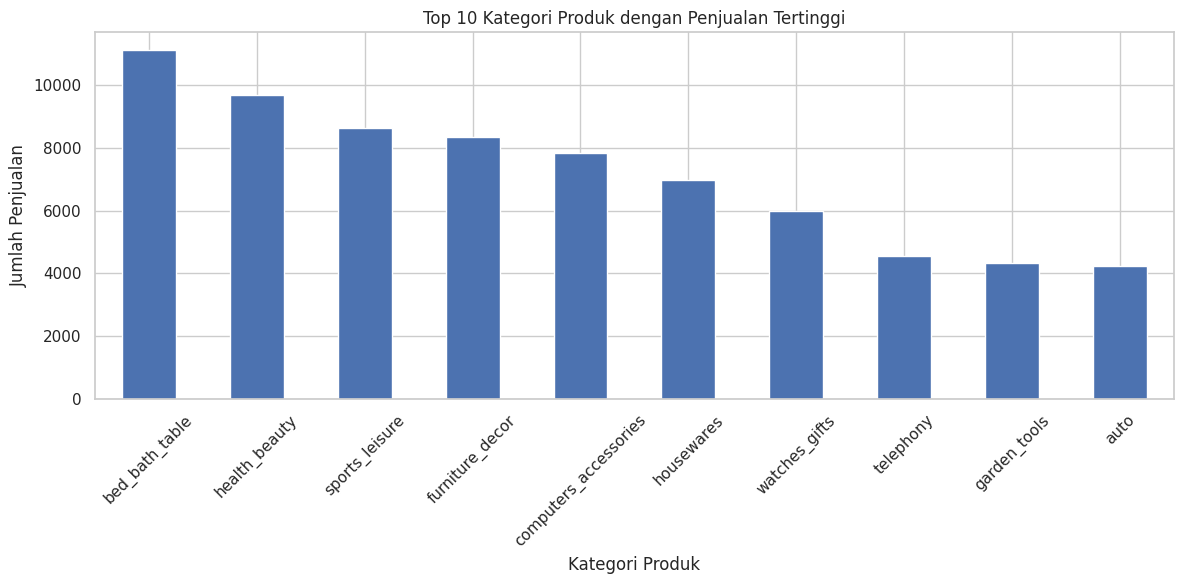

In [8]:
plt.figure(figsize=(12,6))

top_categories.plot(kind="bar")

plt.title("Top 10 Kategori Produk dengan Penjualan Tertinggi")
plt.xlabel("Kategori Produk")
plt.ylabel("Jumlah Penjualan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana segmentasi pelanggan berdasarkan RFM Analysis selama periode September 2016 – Oktober 2018, dan bagaimana karakteristik masing-masing segmen pelanggan?

In [9]:
# Gabungkan orders + order_payments
rfm_df = orders_df.merge(
    order_payments_df,
    on="order_id",
    how="left"
)

# Hitung snapshot date (tanggal terakhir transaksi + 1 hari)
snapshot_date = rfm_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# Hitung RFM
rfm = rfm_df.groupby("customer_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "count",
    "payment_value": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()


,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74
000161a058600d5901f007fab4c27140,459,1,67.41
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42
0002414f95344307404f0ace7a26f1d5,428,1,179.35
000379cdec625522490c315e70c7a9fb,199,1,107.01


**Insight:**
- Pertanyaan 1 :
  - Hasil analisis menunjukkan bahwa kategori produk **bed_bath_table** memiliki jumlah penjualan tertinggi dibandingkan kategori lainnya.

  - Hal ini mengindikasikan bahwa produk-produk yang berkaitan dengan kebutuhan rumah tangga, khususnya perlengkapan kamar tidur dan kamar mandi, memiliki tingkat permintaan yang tinggi di platform e-commerce ini.

  - Dominasi kategori ini menunjukkan bahwa konsumen cenderung menggunakan platform untuk memenuhi kebutuhan rumah tangga sehari-hari. Oleh karena itu, perusahaan dapat mempertimbangkan strategi seperti optimalisasi stok, promosi khusus, atau bundling produk pada kategori ini untuk memaksimalkan pendapatan.

- Pertanyaan 2 :
  - Berdasarkan analisis RFM selama periode September 2016 – Oktober 2018, mayoritas pelanggan memiliki nilai Frequency sebesar 1, yang menunjukkan bahwa sebagian besar pelanggan hanya melakukan satu kali transaksi.
  - Hal ini mengindikasikan tingkat repeat purchase yang masih rendah.
  - Variasi nilai Recency menunjukkan adanya kelompok pelanggan yang masih aktif serta kelompok pelanggan yang sudah lama tidak bertransaksi.
  - Sementara itu, perbedaan nilai Monetary menunjukkan adanya pelanggan dengan kontribusi pendapatan yang jauh lebih tinggi dibandingkan pelanggan lainnya.
  - Segmentasi ini memungkinkan perusahaan mengidentifikasi pelanggan bernilai tinggi dan pelanggan berisiko churn secara lebih terstruktur.
  - Grafik segmentasi menunjukkan bahwa beberapa kombinasi skor RFM memiliki jumlah pelanggan yang dominan. Hal ini dapat digunakan sebagai dasar dalam menentukan prioritas strategi pemasaran berdasarkan karakteristik masing-masing segmen.

## Analisis Lanjutan (Opsional)

In [10]:
rfm["R_score"] = pd.qcut(rfm["Recency"].rank(method="first"), 3, labels=[3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 3, labels=[1,2,3])
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 3, labels=[1,2,3])

In [11]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score'], dtype='object')

In [12]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
customer_id,,,,,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74,2,1,2,212
000161a058600d5901f007fab4c27140,459,1,67.41,1,1,1,111
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42,1,1,3,113
0002414f95344307404f0ace7a26f1d5,428,1,179.35,1,1,3,113
000379cdec625522490c315e70c7a9fb,199,1,107.01,3,1,2,312


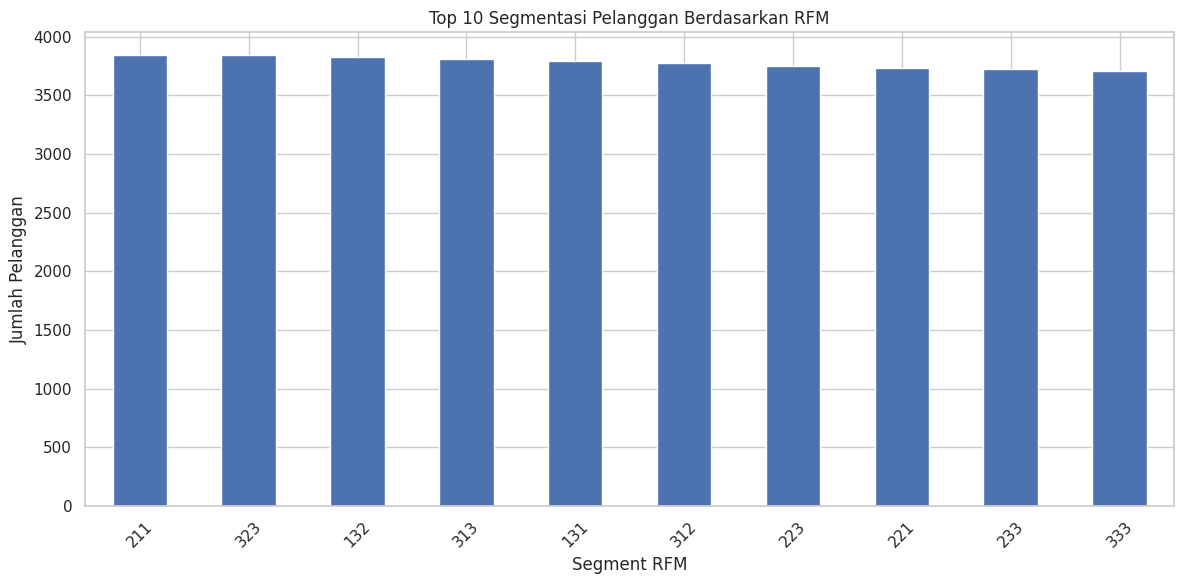

In [13]:
rfm_segment = rfm.groupby("RFM_score").size().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
rfm_segment.plot(kind="bar")
plt.title("Top 10 Segmentasi Pelanggan Berdasarkan RFM")
plt.xlabel("Segment RFM")
plt.ylabel("Jumlah Pelanggan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

- Conclution pertanyaan 1 :
  - Kategori produk bed_bath_table merupakan kategori dengan jumlah penjualan tertinggi dalam dataset e-commerce ini.
Hal ini menunjukkan bahwa produk kebutuhan rumah tangga menjadi kontributor utama dalam aktivitas transaksi di platform.

  - Temuan ini dapat dimanfaatkan oleh perusahaan untuk mengoptimalkan strategi pengelolaan stok, promosi, dan pengembangan produk pada kategori unggulan guna meningkatkan pendapatan secara berkelanjutan.
  - Perusahaan disarankan untuk meningkatkan promosi, menjaga ketersediaan stok, serta melakukan analisis margin keuntungan pada kategori unggulan tersebut guna memaksimalkan kontribusi terhadap pendapatan.

- Conclution pertanyaan 2
  - Berdasarkan analisis RFM, mayoritas pelanggan hanya melakukan satu kali transaksi, yang menunjukkan tingkat repeat purchase yang masih rendah.

  - Segmentasi RFM memungkinkan perusahaan mengidentifikasi pelanggan bernilai tinggi (high-value customers) serta pelanggan dengan risiko churn.

  - Dengan memahami karakteristik tiap segment, perusahaan dapat menerapkan strategi pemasaran yang lebih terarah, seperti program loyalitas untuk pelanggan aktif dan kampanye reaktivasi untuk pelanggan tidak aktif.

  - Dengan demikian, pendekatan berbasis data melalui RFM Analysis dapat membantu meningkatkan retensi pelanggan dan nilai jangka panjang (customer lifetime value).
  
  - Perusahaan dapat menerapkan strategi loyalty program untuk pelanggan dengan skor RFM tinggi serta kampanye reaktivasi (email marketing, diskon khusus) untuk pelanggan dengan nilai Recency tinggi guna meningkatkan retensi dan customer lifetime value.

In [14]:
top_categories_df = top_categories.reset_index()
top_categories_df.columns = ["category", "total_sales"]

top_categories_df.to_csv("main_data.csv", index=False)